<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EC%95%88%EC%98%81%EB%B9%88/YYYELEalgo_MLP%EC%9D%98_%EC%82%AC%EB%B3%B8_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Load
실험 Dataset: California housing

In [30]:
import pandas as pd

CSV_FILEPATH = "/content/merged_features_25C.csv"
df = pd.read_csv(CSV_FILEPATH)

print("데이터 크기 (행, 열):", df.shape)
print("\n컬럼 목록:")
for col in df.columns:
    print(" -", col)

df.head()

데이터 크기 (행, 열): (141, 29)

컬럼 목록:
 - cell_global_id
 - rpt_id
 - aging_condition
 - variance
 - xmean
 - mean3839
 - mean3940
 - mean4041
 - mean4142
 - max
 - min
 - range
 - stdev
 - dcirohm
 - dcir_soc00ohm
 - dcir_soc10ohm
 - dcir_soc20ohm
 - dcir_soc30ohm
 - dcir_soc40ohm
 - dcir_soc50ohm
 - dcir_soc60ohm
 - dcir_soc70ohm
 - dcir_soc80ohm
 - deltat023840
 - deltat103840
 - ctr
 - ccct
 - cvct
 - soh_label_pct


,cell_global_id,rpt_id,aging_condition,variance,xmean,mean3839,mean3940,mean4041,mean4142,max,...,dcir_soc50ohm,dcir_soc60ohm,dcir_soc70ohm,dcir_soc80ohm,deltat023840,deltat103840,ctr,ccct,cvct,soh_label_pct
0,1,0,LOW C@ 25°C #1,0.007519,0.294405,0.238540,0.287085,0.247514,0.409893,0.463239,...,0.025000,0.025000,0.021667,0.023333,4140.0,793.333333,0.191626,3140,443.05,100.000000
1,1,1,LOW C@ 25°C #1,0.008914,0.298118,0.253707,0.288757,0.239441,0.416074,0.471264,...,0.026667,0.025000,0.023333,0.023333,4050.0,786.666667,0.194239,2870,455.05,93.108019
2,1,2,LOW C@ 25°C #1,0.009736,0.302310,0.258539,0.295900,0.244835,0.415268,0.472016,...,0.028333,0.026667,0.025000,0.025000,4020.0,770.000000,0.191542,2720,458.15,89.463221
3,1,3,LOW C@ 25°C #1,0.010022,0.302330,0.259584,0.297045,0.245275,0.412607,0.469879,...,0.030000,0.026667,0.026667,0.025000,4000.0,765.000000,0.191250,2650,460.65,87.773360
4,1,4,LOW C@ 25°C #1,0.010921,0.311753,0.267694,0.308545,0.256374,0.419489,0.478524,...,0.030000,0.026667,0.028333,0.028333,4000.0,755.000000,0.188750,2570,475.70,86.249172


# Config

* 라이브러리 불러오기
* hyperparameter 조정

In [31]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


# hyperparamter 조정
CONFIG = {
    "batch_size": 5,
    "epochs": 1000,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "patience": 10,
    "random_seed": 42
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(CONFIG["random_seed"])

# 기본 실행 코드
MLP 구조: N -> 16 -> 8 ->1

In [32]:
# 데이터셋 클래스 (CSV 파일 읽기)
class BatteryCSVDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# MLP 모델 클래스
class SOHPredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# Dataset Loader
*   Feature, Target 설정
*   Dataset Split: Train 8 / Val 1 / Test 1




In [33]:
CSV_FILENAME = "merged_features_25C.csv"

# Feature, Target 설정
FEATURES = [
    "variance",
    "xmean",
    "mean4142",
    "max",
    "min",
    #"range",
    #"stdev",
    "dcirohm",
    "dcir_soc50ohm",
    "deltat023840",
    "ctr",
    "ccct",
    "cvct"
]
TARGET = "soh_label_pct"

# 이번 실험 이름
EXPERIMENT_NAME = "11_no_range_no stdev"

# 실험 결과 누적 저장
if "experiment_results" not in globals():
    experiment_results = []

##다중공정성체크
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X_vif = df[FEATURES].dropna()

# 절편 추가
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = FEATURES
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(1, X_vif_const.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

print(vif_data)

##여기까지

df = pd.read_csv(CSV_FILENAME)


# =========================================================
# Cell 단위 Train / Validation / Test 분리
# =========================================================

# aging_condition에서 #1, #2 ... 제거
# 예: "LOW C@ 25°C #1" -> "LOW C@ 25°C"
df["condition_base"] = df["aging_condition"].str.replace(
    r"\s*#\d+\s*$",
    "",
    regex=True
)

# Cell별 조건표
cell_info = df[
    ["cell_global_id", "condition_base"]
].drop_duplicates()


# ---------------------------------------------------------
# 1) 각 조건에서 physical cell 1개를 Final Test로 선택
# ---------------------------------------------------------
test_cells = (
    cell_info
    .groupby("condition_base", group_keys=False)
    .sample(n=1, random_state=42)
)

remaining_cells = cell_info[
    ~cell_info["cell_global_id"].isin(
        test_cells["cell_global_id"]
    )
]


# ---------------------------------------------------------
# 2) 남은 데이터에서 각 조건당 1 cell을 Validation으로 선택
# ---------------------------------------------------------
val_cells = (
    remaining_cells
    .groupby("condition_base", group_keys=False)
    .sample(n=1, random_state=43)
)

train_cells = remaining_cells[
    ~remaining_cells["cell_global_id"].isin(
        val_cells["cell_global_id"]
    )
]


# Cell ID 추출
train_cell_ids = train_cells["cell_global_id"].values
val_cell_ids   = val_cells["cell_global_id"].values
test_cell_ids  = test_cells["cell_global_id"].values


# 실제 행 데이터 분리
df_train = df[
    df["cell_global_id"].isin(train_cell_ids)
].copy()

df_val = df[
    df["cell_global_id"].isin(val_cell_ids)
].copy()

df_test = df[
    df["cell_global_id"].isin(test_cell_ids)
].copy()


# ---------------------------------------------------------
# Cell leakage 확인
# ---------------------------------------------------------
assert set(train_cell_ids).isdisjoint(set(val_cell_ids))
assert set(train_cell_ids).isdisjoint(set(test_cell_ids))
assert set(val_cell_ids).isdisjoint(set(test_cell_ids))


print("Train cells:", sorted(train_cell_ids))
print("Validation cells:", sorted(val_cell_ids))
print("Test cells:", sorted(test_cell_ids))

print()
print("Train cell 수:", len(train_cell_ids))
print("Validation cell 수:", len(val_cell_ids))
print("Test cell 수:", len(test_cell_ids))

print()
print("Train rows:", len(df_train))
print("Validation rows:", len(df_val))
print("Test rows:", len(df_test))


# ---------------------------------------------------------
# Feature / Target 분리
# 아직 Scaling 하지 않음
# ---------------------------------------------------------
X_train_raw = df_train[FEATURES].values
y_train = df_train[TARGET].values

X_val_raw = df_val[FEATURES].values
y_val = df_val[TARGET].values

X_test_raw = df_test[FEATURES].values
y_test = df_test[TARGET].values

#-----# =========================================================
# VIF + Adjusted R²
# Train 데이터만 사용
# =========================================================

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd


# Train 데이터만 사용
stats_df = df_train[
    FEATURES + [TARGET]
].dropna()


# ---------------------------------------------------------
# VIF
# ---------------------------------------------------------
X_vif = stats_df[FEATURES]

X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame()

vif_data["Feature"] = FEATURES

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif_const.values,
        i
    )
    for i in range(1, X_vif_const.shape[1])
]

vif_data = vif_data.sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)


print("===== VIF =====")
display(vif_data)


# ---------------------------------------------------------
# OLS R² / Adjusted R²
# ---------------------------------------------------------
X_ols = add_constant(
    stats_df[FEATURES]
)

y_ols = stats_df[TARGET]

ols_model = sm.OLS(
    y_ols,
    X_ols
).fit()

r2_ols = ols_model.rsquared
adjusted_r2 = ols_model.rsquared_adj

print()
print(f"OLS R²          : {r2_ols:.6f}")
print(f"OLS Adjusted R² : {adjusted_r2:.6f}")



#----------------------------여기까지 새로추가
# =========================================================
# Standard Scaling
# Train 데이터로만 scaler 학습
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)

X_val = scaler.transform(X_val_raw)

X_test = scaler.transform(X_test_raw)

train_dataset = BatteryCSVDataset(X_train, y_train)
val_dataset = BatteryCSVDataset(X_val, y_val)
test_dataset = BatteryCSVDataset(X_test, y_test)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

# Train/Val/Test 별 Data 개수 출력
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))



import random
import numpy as np
import torch

seed = CONFIG["random_seed"]

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


model = SOHPredictorMLP(
    input_dim=len(FEATURES)
)

          Feature         VIF
3             max  364.708401
1           xmean  347.964941
2        mean4142  255.633298
0        variance  139.625802
9            ccct   71.211208
5         dcirohm   67.837180
4             min   62.868484
6   dcir_soc50ohm   33.304526
8             ctr   19.189532
7    deltat023840   12.092393
10           cvct    7.063575
Train cells: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(16), np.int64(19), np.int64(20), np.int64(21), np.int64(23)]
Validation cells: [np.int64(5), np.int64(9), np.int64(15), np.int64(17), np.int64(22)]
Test cells: [np.int64(7), np.int64(10), np.int64(14), np.int64(18), np.int64(24)]

Train cell 수: 14
Validation cell 수: 5
Test cell 수: 5

Train rows: 87
Validation rows: 28
Test rows: 26
===== VIF =====


,Feature,VIF
0,xmean,381.523551
1,max,361.795463
2,mean4142,199.328271
3,variance,105.455492
4,dcirohm,73.849015
5,min,61.587195
6,ccct,58.260560
7,dcir_soc50ohm,37.867026
8,ctr,18.458265
9,deltat023840,8.760682



OLS R²          : 0.997647
OLS Adjusted R² : 0.997301
Train: 87
Validation: 28
Test: 26


# Epoch 실행

*   Loss: MSE
*   Optimizer: Adam
*   Weight decay 적용: overfitting 방지
*   Learning rate Scheduler: 기준 5번
*   Early Stopping: 기준 Config에서 설정





In [34]:
model = SOHPredictorMLP(input_dim=len(FEATURES))

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"])

# Learning rate Schedler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")
patience_count = 0

train_losses = []
val_losses = []

# Epoch 실행
for epoch in range(1, CONFIG["epochs"] + 1):

    model.train()
    train_loss = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred_y = model(batch_x)
        loss = criterion(pred_y, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:
            pred_y = model(batch_x)
            loss = criterion(pred_y, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


    # best validation 값 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        patience_count = 0

        torch.save(
            model.state_dict(),
            "best_mlp_model.pth")
    else:
        patience_count += 1

    # Early Stopping -> 기준 config에서 설정
    if patience_count >= CONFIG["patience"]:
        print("Early stopping")
        break

Epoch [1/1000] Train Loss: 7869.2065 Val Loss: 7816.1327
Epoch [2/1000] Train Loss: 7892.1105 Val Loss: 7803.8363
Epoch [3/1000] Train Loss: 7835.3505 Val Loss: 7789.5569
Epoch [4/1000] Train Loss: 7843.4487 Val Loss: 7770.0823
Epoch [5/1000] Train Loss: 7763.0213 Val Loss: 7738.5188
Epoch [6/1000] Train Loss: 7801.4932 Val Loss: 7696.1377
Epoch [7/1000] Train Loss: 7684.5154 Val Loss: 7640.3540
Epoch [8/1000] Train Loss: 7668.8886 Val Loss: 7568.3803
Epoch [9/1000] Train Loss: 7563.5941 Val Loss: 7475.0030
Epoch [10/1000] Train Loss: 7470.0290 Val Loss: 7357.5093
Epoch [11/1000] Train Loss: 7355.9404 Val Loss: 7212.3861
Epoch [12/1000] Train Loss: 7208.8081 Val Loss: 7032.9962
Epoch [13/1000] Train Loss: 7035.5945 Val Loss: 6809.2394
Epoch [14/1000] Train Loss: 6823.5447 Val Loss: 6559.3578
Epoch [15/1000] Train Loss: 6562.8750 Val Loss: 6265.6196
Epoch [16/1000] Train Loss: 6276.0253 Val Loss: 5949.2991
Epoch [17/1000] Train Loss: 5970.6738 Val Loss: 5585.6478
Epoch [18/1000] Train L

# Loss Curve




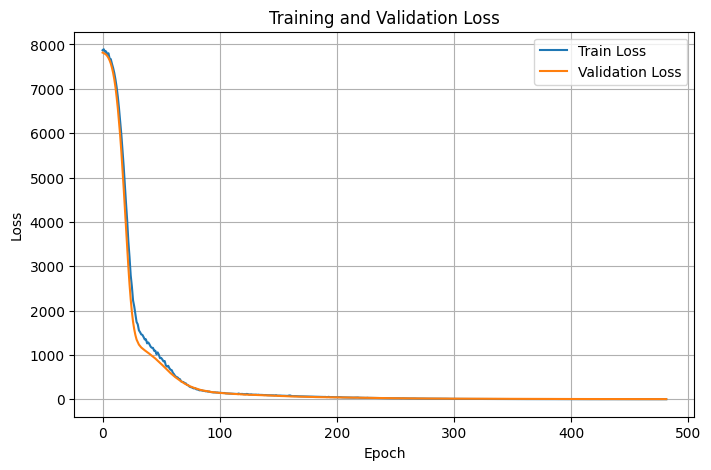

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss")

plt.plot(
    val_losses,
    label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

# Result

In [36]:
model.load_state_dict(torch.load("best_mlp_model.pth"))
model.eval()

# =========================================================
# Best model의 Train / Validation 성능 측정
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error


def evaluate_loader(model, loader):

    model.eval()

    actuals = []
    predictions = []

    with torch.no_grad():

        for batch_x, batch_y in loader:

            pred_y = model(batch_x)

            actuals.extend(
                batch_y.cpu().numpy().flatten()
            )

            predictions.extend(
                pred_y.cpu().numpy().flatten()
            )

    actuals = np.array(actuals)
    predictions = np.array(predictions)

    mse = mean_squared_error(
        actuals,
        predictions
    )

    rmse = np.sqrt(mse)

    return mse, rmse


# Train 성능
train_mse, train_rmse = evaluate_loader(
    model,
    train_loader
)

# Validation 성능
val_mse, val_rmse = evaluate_loader(
    model,
    val_loader
)


print(f"Train MSE       : {train_mse:.4f}")
print(f"Train RMSE      : {train_rmse:.4f}")

print()

print(f"Validation MSE  : {val_mse:.4f}")
print(f"Validation RMSE : {val_rmse:.4f}")

#---------------------
# =========================================================
# Feature 실험 결과 자동 누적
# =========================================================

max_vif = vif_data["VIF"].max()

best_epoch = int(
    np.argmin(val_losses) + 1
)


# 같은 이름의 실험을 다시 실행했다면
# 이전 기록 제거
experiment_results = [
    r for r in experiment_results
    if r["Experiment"] != EXPERIMENT_NAME
]


experiment_results.append({

    "Experiment":
        EXPERIMENT_NAME,

    "Feature Count":
        len(FEATURES),

    "Max VIF":
        max_vif,

    "Adjusted R2":
        adjusted_r2,

    "Best Epoch":
        best_epoch,

    "Train MSE":
        train_mse,

    "Train RMSE":
        train_rmse,

    "Validation MSE":
        val_mse,

    "Validation RMSE":
        val_rmse,

    "Features":
        ", ".join(FEATURES)
})


result_table = pd.DataFrame(
    experiment_results
)

display(result_table)

#-------------------------------여기까지가 표 보여주기

predictions = []
actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        pred_y = model(batch_x)

        predictions.extend(pred_y.numpy().flatten())
        actuals.extend(batch_y.numpy().flatten())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Test Loss
test_loss = mean_squared_error(actuals, predictions)

print("Test Loss:", round(test_loss, 4))

# 무작위 10개 결과 확인
random_indices = np.random.choice(
    len(actuals),
    size=10,
    replace=False
)

sample_actuals = actuals[random_indices]
sample_predictions = predictions[random_indices]

abs_error = np.abs(sample_actuals - sample_predictions)
error_rate_pct = (abs_error / np.maximum(np.abs(sample_actuals), 1e-8)) * 100

result_df = pd.DataFrame({
    "Actual": np.round(sample_actuals, 4),
    "Prediction": np.round(sample_predictions, 4),
    "Absolute Error": np.round(abs_error, 4),
    "Error Rate (%)": np.round(error_rate_pct, 2)})

print("\nPrediction Result")
print(result_df.to_string(index=False))

Train MSE       : 1.6148
Train RMSE      : 1.2708

Validation MSE  : 3.8249
Validation RMSE : 1.9557


,Experiment,Feature Count,Max VIF,Adjusted R2,Best Epoch,Train MSE,Train RMSE,Validation MSE,Validation RMSE,Features
0,13_original,13,1.000800e+15,0.997243,406,3.760494,1.939199,8.135386,2.852260,"variance, xmean, mean4142, max, min, range, st..."
1,12_no_range,12,9.131756e+03,0.997265,602,0.489422,0.699587,2.085807,1.444232,"variance, xmean, mean4142, max, min, stdev, dc..."
2,11_no_range_no stdev,11,3.815236e+02,0.997301,472,1.614809,1.270751,3.824949,1.955748,"variance, xmean, mean4142, max, min, dcirohm, ..."


Test Loss: 2.7265

Prediction Result
    Actual  Prediction  Absolute Error  Error Rate (%)
 88.944099   89.163200          0.2192            0.25
100.000000  101.268501          1.2685            1.27
100.000000   98.332199          1.6678            1.67
 86.773903   87.887100          1.1133            1.28
100.000000  101.283798          1.2838            1.28
 84.773300   85.231102          0.4579            0.54
 88.570503   89.512398          0.9419            1.06
 92.659599   93.136299          0.4767            0.51
 92.484398   89.571999          2.9124            3.15
 81.731400   81.161400          0.5700            0.70
